# Brent Oil Price Change Point Analysis

## Exploratory Data Analysis (EDA)

### Week 10 Challenge

**Author:** E. Frida N.

---

### Project Objective

This notebook performs the initial exploratory analysis of historical Brent crude oil prices. The objective is to understand long-term trends, volatility patterns, and statistical properties of the data before applying Bayesian Change Point Analysis. The insights generated in this notebook provide the foundation for identifying structural breaks and associating them with major geopolitical and economic events.


In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [20]:
import sys
print(sys.executable)

c:\Users\nfepo\Downloads\10 Academy\W10\brent-oil-change-point-analysis\venv\Scripts\python.exe


In [21]:
from statsmodels.tsa.stattools import adfuller

In [22]:
# Load the Brent oil price dataset
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [23]:
import pandas as pd

print(pd.__version__)

3.0.3


In [24]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [26]:
# ============================================================
# Dataset Overview
# ============================================================

print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("Data Types")
print("="*50)
print(df.dtypes)

print("\n")

print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("Summary Statistics")
print("="*50)
print(df.describe())

Dataset Shape
(9011, 2)


Data Types
Date         str
Price    float64
dtype: object


Missing Values
Date     0
Price    0
dtype: int64


Summary Statistics
             Price
count  9011.000000
mean     48.420782
std      32.860110
min       9.100000
25%      19.050000
50%      38.570000
75%      70.090000
max     143.950000


In [27]:
# ============================================================
# Convert Date Column
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [28]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y"
)

In [29]:
# ============================================================
# Set Date Index
# ============================================================

df.set_index("Date", inplace=True)

df.head()

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


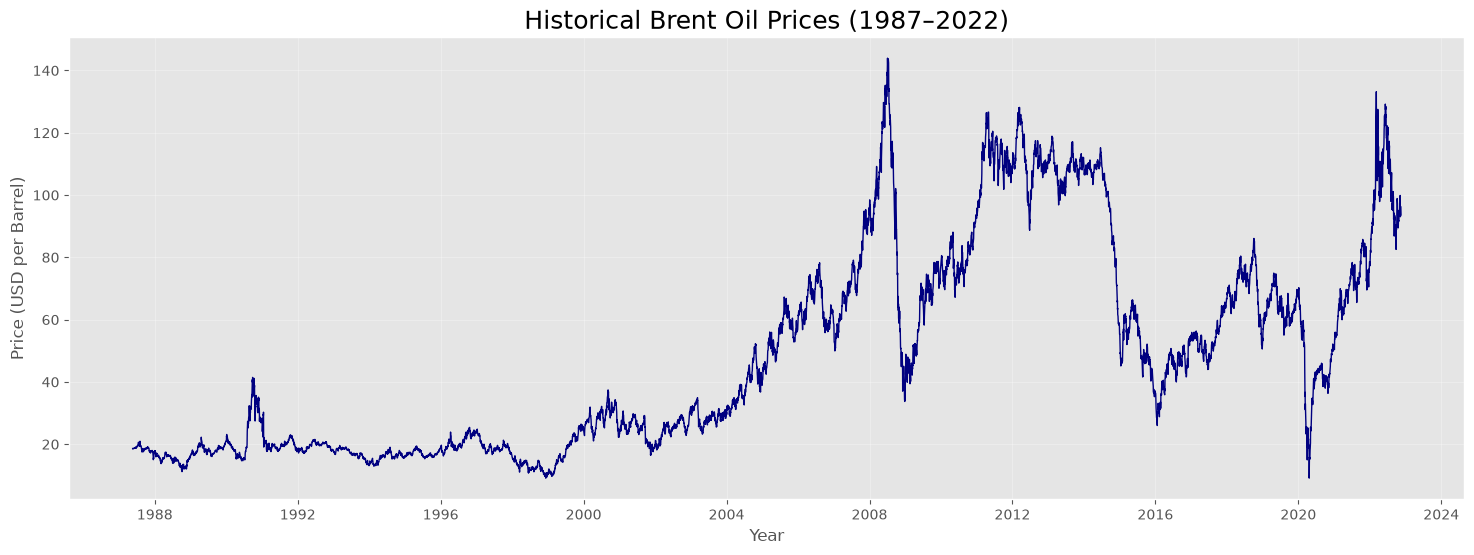

In [30]:
# ============================================================
# Brent Oil Prices
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(df.index,
         df["Price"],
         color="navy",
         linewidth=1)

plt.title("Historical Brent Oil Prices (1987–2022)",
          fontsize=18)

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.grid(alpha=0.3)

plt.show()

## Time Series Exploration

Before applying Bayesian Change Point Detection, it is important to understand the statistical characteristics of the Brent oil price series. This section explores the overall trend, rolling statistics, distribution of prices, and daily price changes to identify patterns that may influence model selection.

In [33]:
# ============================================================
# Check for Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate records: {duplicates}")

Duplicate records: 3996


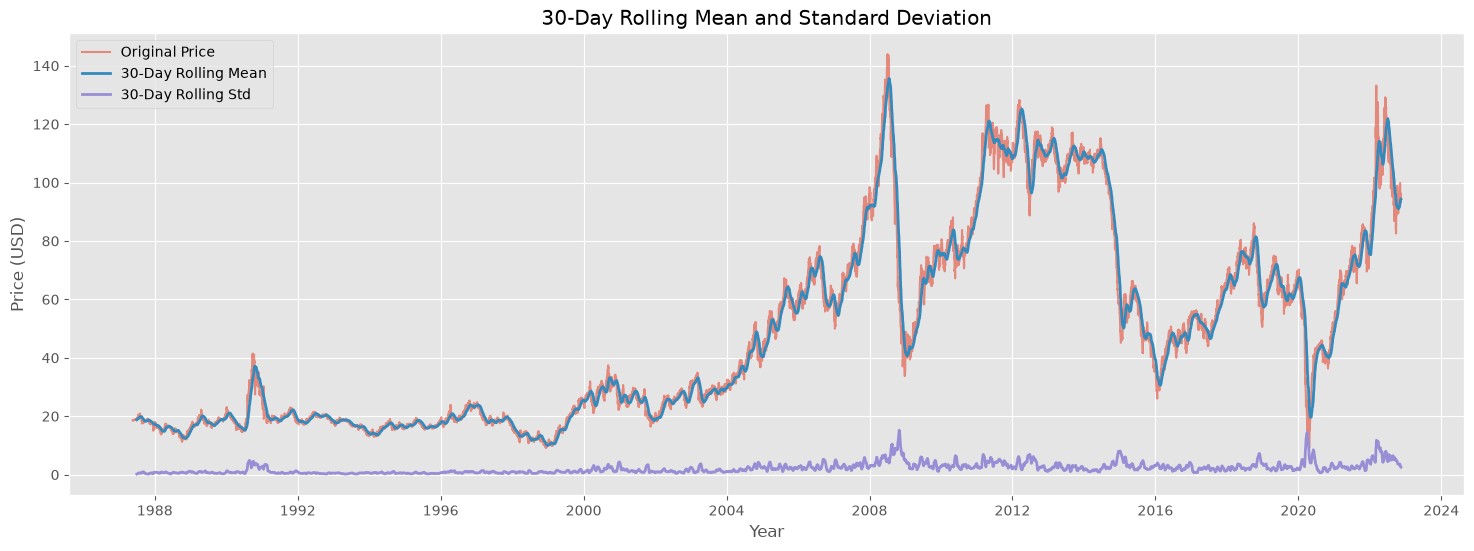

In [34]:
# ============================================================
# Rolling Statistics
# ============================================================

rolling_mean = df["Price"].rolling(window=30).mean()
rolling_std = df["Price"].rolling(window=30).std()

plt.figure(figsize=(18,6))

plt.plot(df["Price"], label="Original Price", alpha=0.6)
plt.plot(rolling_mean, label="30-Day Rolling Mean", linewidth=2)
plt.plot(rolling_std, label="30-Day Rolling Std", linewidth=2)

plt.title("30-Day Rolling Mean and Standard Deviation")

plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()

plt.show()

### Observation

The rolling mean and rolling standard deviation vary considerably over time, indicating that the Brent oil price series is not stationary. Several periods exhibit substantial increases in volatility, particularly during major global economic and geopolitical events. These observations support the need for change point analysis rather than assuming a constant statistical process throughout the series.

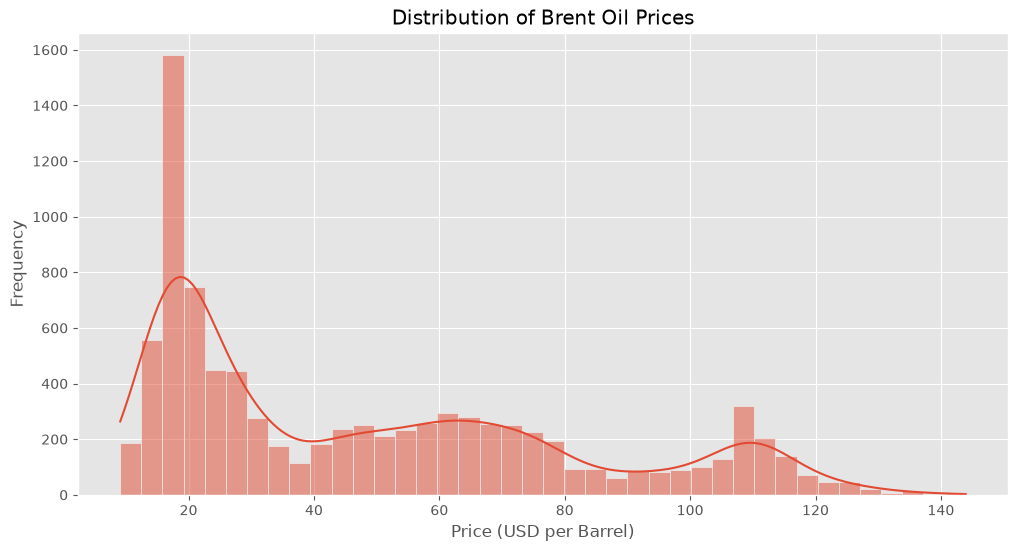

In [35]:
# ============================================================
# Distribution of Brent Oil Prices
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df["Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Brent Oil Prices")

plt.xlabel("Price (USD per Barrel)")
plt.ylabel("Frequency")

plt.show()

### Observation

The price distribution is not perfectly symmetric and exhibits multiple peaks, suggesting that Brent crude prices have experienced different market regimes over the observation period. This further motivates the use of structural break detection methods.

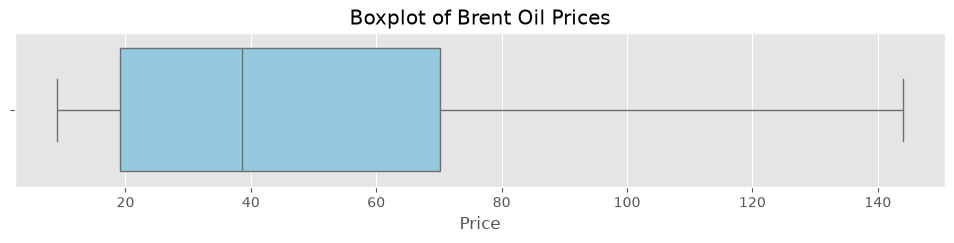

In [36]:
# ============================================================
# Boxplot
# ============================================================

plt.figure(figsize=(12,2))

sns.boxplot(
    x=df["Price"],
    color="skyblue"
)

plt.title("Boxplot of Brent Oil Prices")

plt.show()

### Observation

The boxplot reveals several extreme price observations. These are expected in financial time series and correspond to major geopolitical shocks, economic crises, and significant OPEC production decisions rather than data quality issues.

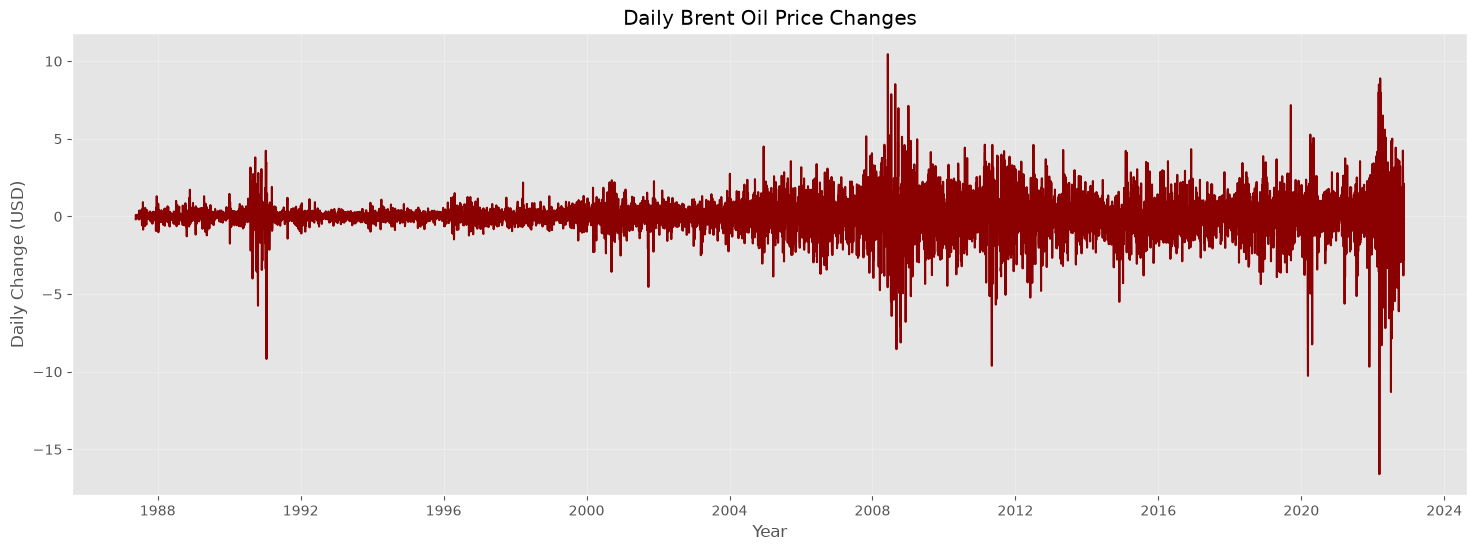

In [37]:
# ============================================================
# Daily Price Difference
# ============================================================

df["Price_Change"] = df["Price"].diff()

plt.figure(figsize=(18,6))

plt.plot(
    df["Price_Change"],
    color="darkred"
)

plt.title("Daily Brent Oil Price Changes")

plt.xlabel("Year")
plt.ylabel("Daily Change (USD)")

plt.grid(alpha=0.3)

plt.show()

## Stationarity Analysis

Many statistical models assume that a time series is stationary, meaning its statistical properties such as mean and variance remain constant over time. Before applying Bayesian Change Point Analysis, we test whether the Brent oil price series is stationary using the Augmented Dickey-Fuller (ADF) test.

In [38]:
# ============================================================
# Augmented Dickey-Fuller Test
# ============================================================

from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Price"])

print("="*60)
print("Augmented Dickey-Fuller Test")
print("="*60)

print(f"ADF Statistic : {result[0]:.4f}")
print(f"P-value       : {result[1]:.6f}")
print(f"Lags Used     : {result[2]}")
print(f"Observations  : {result[3]}")

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

Augmented Dickey-Fuller Test
ADF Statistic : -1.9939
P-value       : 0.289274
Lags Used     : 29
Observations  : 8981

Critical Values:
1%: -3.4311
5%: -2.8619
10%: -2.5669


### Interpretation

The ADF test evaluates the null hypothesis that the time series contains a unit root (is non-stationary).

- If the p-value is less than 0.05, we reject the null hypothesis and conclude that the series is stationary.
- If the p-value is greater than 0.05, the series is considered non-stationary.

Given the long-term upward trend and changing volatility observed in Brent oil prices, we expect the original price series to be non-stationary.

## Log Returns

Financial time series are often transformed into log returns because returns tend to exhibit more stable statistical properties than raw prices. This transformation reduces trends and allows changes in volatility to be analysed more effectively.

In [39]:
# ============================================================
# Log Returns
# ============================================================

df["Log_Return"] = np.log(df["Price"] / df["Price"].shift(1))

df.head()

,Price,Price_Change,Log_Return
Date,,,
1987-05-20,18.63,NaN,NaN
1987-05-21,18.45,-0.18,-0.009709
1987-05-22,18.55,0.10,0.005405
1987-05-25,18.60,0.05,0.002692
1987-05-26,18.63,0.03,0.001612


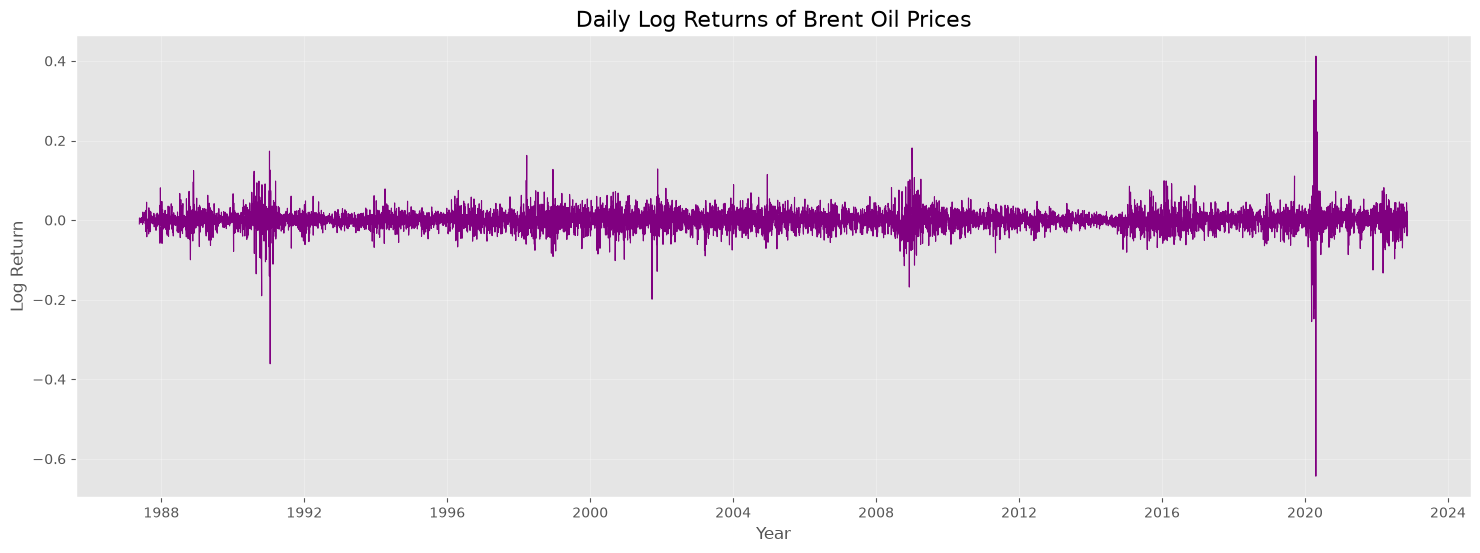

In [40]:
# ============================================================
# Plot Log Returns
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(
    df.index,
    df["Log_Return"],
    color="purple",
    linewidth=0.8
)

plt.title("Daily Log Returns of Brent Oil Prices", fontsize=16)

plt.xlabel("Year")
plt.ylabel("Log Return")

plt.grid(alpha=0.3)

plt.show()

### Observation

The log return series fluctuates around zero, with periods of increased volatility corresponding to major global events. Compared to the original price series, log returns display more stable behaviour, making them more appropriate for statistical modelling and volatility analysis.

In [41]:
# ============================================================
# ADF Test on Log Returns
# ============================================================

log_returns = df["Log_Return"].dropna()

result = adfuller(log_returns)

print("="*60)
print("ADF Test on Log Returns")
print("="*60)

print(f"ADF Statistic : {result[0]:.4f}")
print(f"P-value       : {result[1]:.6f}")

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

ADF Test on Log Returns
ADF Statistic : -16.4271
P-value       : 0.000000

Critical Values:
1%: -3.4311
5%: -2.8619
10%: -2.5669


### Interpretation

The log return series is expected to be stationary because differencing removes much of the long-term trend present in the original price series. If confirmed by the ADF test, this supports the use of returns when analysing volatility and validating assumptions underlying statistical models.

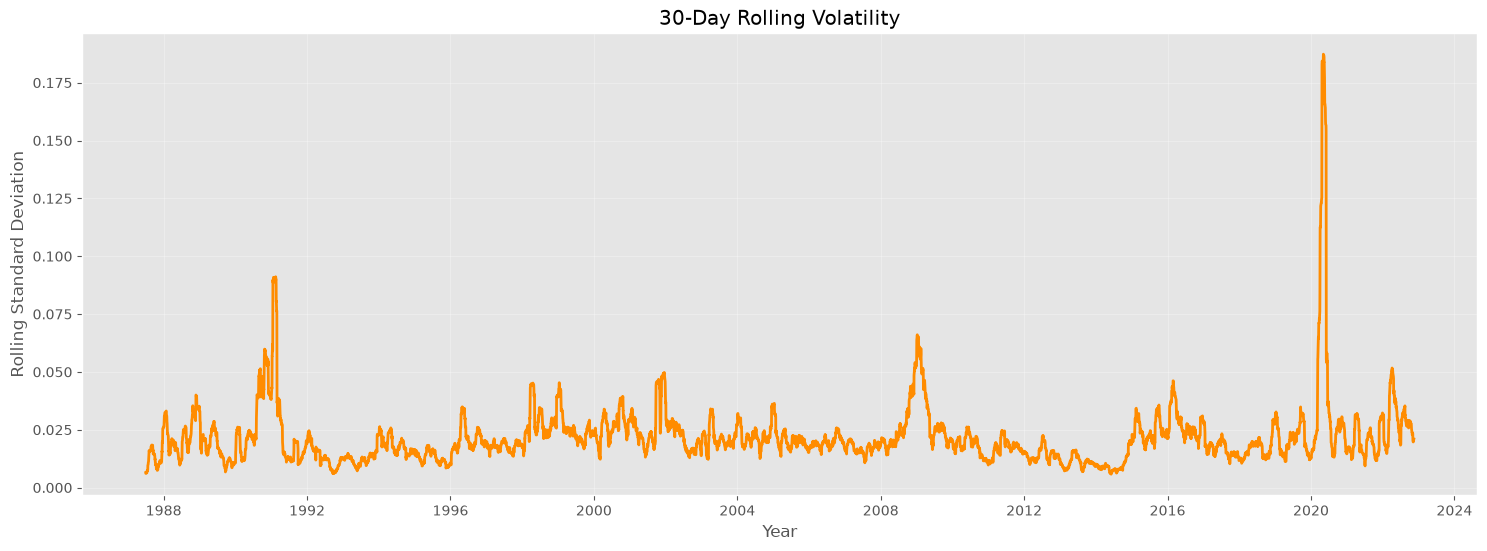

In [42]:
# ============================================================
# Volatility Clustering
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(
    df.index,
    df["Log_Return"].rolling(30).std(),
    color="darkorange",
    linewidth=2
)

plt.title("30-Day Rolling Volatility")

plt.xlabel("Year")
plt.ylabel("Rolling Standard Deviation")

plt.grid(alpha=0.3)

plt.show()

### Observation

The rolling volatility demonstrates clear periods of volatility clustering, where large price movements are followed by additional periods of high variability. This behaviour is characteristic of financial markets and reinforces the suitability of Bayesian Change Point Analysis for detecting structural shifts in the Brent oil price series.